In [1]:
import io
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
def carregar_amostra_proporcional_scr(ano=2024, n_amostra_total=50000, chunksize=100000):
    """
    Baixa o dataset oficial do SCR.data do Banco Central do Brasil, lê o arquivo em blocos
    e gera uma amostra estratificada mantendo a proporção exata de cada UF no país.
    """
    url = f"https://www.bcb.gov.br/pda/desig/scrdata_{ano}.zip"
    print(f"Baixando arquivo oficial do SCR.data (Ano: {ano})...")
    print(f"URL: {url}")
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    resp = requests.get(url, headers=headers, stream=True, timeout=120)
    resp.raise_for_status()

    amostras_list = []
    
    print("Processando ZIP em streaming de blocos (chunks)...")
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        arquivos_internos = [f for f in z.namelist() if f.endswith(".csv") or f.endswith(".txt")]
        if not arquivos_internos:
            raise FileNotFoundError("Nenhum arquivo CSV encontrado dentro do ZIP do BCB.")
            
        csv_filename = arquivos_internos[0]
        print(f"Extraindo arquivo interno: {csv_filename}")
        
        with z.open(csv_filename) as f:
            # Lê em chunks para não estourar a memória RAM
            reader = pd.read_csv(
                        f,
                        sep=";",
                        encoding="utf-8-sig",  
                        chunksize=chunksize,
                        low_memory=False,
                    )
            
            # Extrai 5% de cada bloco mantendo a distribuição geográfica
            for chunk in reader:
                amostra_chunk = chunk.sample(frac=0.05, random_state=42)
                amostras_list.append(amostra_chunk)
                
    df_amostrado = pd.concat(amostras_list, ignore_index=True)
    
    # Identifica a coluna de UF
    col_uf = [c for c in df_amostrado.columns if 'uf' in c.lower()][0]

    # Re-amostragem estratificada mantendo as proporções populacionais idênticas às do BCB
    df_final = (
        df_amostrado.groupby(col_uf, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, n_amostra_total / len(df_amostrado)), random_state=42))
        .reset_index(drop=True)
    )
    
    print(f"Sucesso! Amostra criada com {len(df_final)} linhas cobrindo as UFs do Brasil.")
    return df_final

# Carrega 50.000 registros mantendo a distribuição nacional
df_scr_raw = carregar_amostra_proporcional_scr(ano=2024, n_amostra_total=50000)

Baixando arquivo oficial do SCR.data (Ano: 2024)...
URL: https://www.bcb.gov.br/pda/desig/scrdata_2024.zip


Processando ZIP em streaming de blocos (chunks)...
Extraindo arquivo interno: scrdata_202401.csv
Sucesso! Amostra criada com 15585 linhas cobrindo as UFs do Brasil.


C:\Users\adria\AppData\Local\Temp\ipykernel_2984\41295168.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=min(1.0, n_amostra_total / len(df_amostrado)), random_state=42))


In [3]:
pd.set_option('display.max_columns', None)
df_scr_raw.head()

,data_base,uf,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,numero_de_operacoes,a_vencer_ate_90_dias,a_vencer_de_91_ate_360_dias,a_vencer_de_361_ate_1080_dias,a_vencer_de_1081_ate_1800_dias,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico
0,2024-01-31,AC,Financeira,PF,Servidor ou empregado público,Mais de 3 a 5 salários mínimos,Outros créditos,Outros com característica de crédito,Sem destinação específica,Prefixado,60,"278,06","0,00","0,00","0,00","0,00","0,00","278,06","1749,58","9807,84","11557,42","11835,48","9807,84","10256,73"
1,2024-01-31,AC,Banco,PJ,Comércio; reparação de veículos automotores e ...,Médio,Financiamentos,Outros financiamentos,Sem destinação específica,Flutuantes,8,"95439,77","263028,07","347534,62","74976,32","0,00","0,00","780978,78","0,00","0,00","0,00","780978,78","0,00","0,00"
2,2024-01-31,AC,Fintech,PF,Outros,Até 1 salário mínimo,Empréstimos,Crédito pessoal - sem consignação em folha de ...,Sem destinação específica,Prefixado,125,"15120,42","15576,13","20406,43","8557,26","2717,95","0,00","62378,19","3331,35","2599,94","5931,29","68309,48","7272,34","8379,25"
3,2024-01-31,AC,Banco,PF,Outros,Indisponível,Empréstimos,Crédito pessoal - com consignação em folha de ...,Sem destinação específica,Outros indexadores,130,"144317,69","384836,91","743478,78","453106,24","146420,64","0,00","1872160,26","749,35","0,00","749,35","1872909,61","0,00","0,00"
4,2024-01-31,AC,Banco,PF,Outros,Até 1 salário mínimo,Financiamentos rurais (ex-financiamentos rura...,Custeio,Sem destinação específica,Prefixado,7,"0,00","0,00","0,00","0,00","0,00","60508,92","60508,92","0,00","0,00","0,00","60508,92","0,00","60508,92"


In [4]:
# Remove espaços dos nomes das colunas
df_scr_raw.columns = df_scr_raw.columns.str.strip().str.lower()

# Converte colunas com valores em R$ formatadas com vírgula (ex: '1500,50') para float
for col in df_scr_raw.columns:
    if df_scr_raw[col].dtype == 'object':
        amostra_val = df_scr_raw[col].dropna().iloc[0] if not df_scr_raw[col].dropna().empty else ''
        if isinstance(amostra_val, str) and (',' in amostra_val and amostra_val.replace(',', '').replace('.', '').replace('-', '').isdigit()):
            df_scr_raw[col] = (
                df_scr_raw[col]
                .astype(str)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.', regex=False)
                .astype(float)
            )

print("Formatação de tipos e colunas monetárias em R$ concluída!")

Formatação de tipos e colunas monetárias em R$ concluída!


In [5]:
print("--- SCHEMA DAS COLUNAS DO SCR.DATA ---")
df_schema = pd.DataFrame({
    "Coluna": df_scr_raw.columns,
    "Tipo_Dado": df_scr_raw.dtypes.values,
    "Nulos": df_scr_raw.isnull().sum().values,
    "Nulos_%": (df_scr_raw.isnull().sum() / len(df_scr_raw) * 100).round(2),
    "Valores_Unicos": [df_scr_raw[col].nunique() for col in df_scr_raw.columns]
})

df_schema

--- SCHEMA DAS COLUNAS DO SCR.DATA ---


,Coluna,Tipo_Dado,Nulos,Nulos_%,Valores_Unicos
data_base,data_base,object,0,0.0,1
uf,uf,object,0,0.0,27
segmento,segmento,object,0,0.0,8
cliente,cliente,object,0,0.0,2
cnae_ocupacao,cnae_ocupacao,object,0,0.0,30
porte,porte,object,0,0.0,13
modalidade,modalidade,object,0,0.0,13
submodalidade,submodalidade,object,0,0.0,53
origem,origem,object,0,0.0,2
indexador,indexador,object,0,0.0,6


In [6]:
col_uf = [c for c in df_scr_raw.columns if 'uf' in c.lower()][0]

df_distribuicao = (
    df_scr_raw[col_uf]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

df_distribuicao.columns = ["UF", "Proporção na Amostra (%)"]
df_distribuicao["Volume de Registros"] = df_scr_raw[col_uf].value_counts().values

print(f"Total de UFs na Amostra: {df_scr_raw[col_uf].nunique()} de 27")
df_distribuicao

Total de UFs na Amostra: 27 de 27


,UF,Proporção na Amostra (%),Volume de Registros
0,SP,6.54,1020
1,RS,6.17,962
2,MG,6.10,950
3,SC,5.89,918
4,PR,5.88,916
5,GO,4.66,727
6,RJ,4.59,715
7,MT,4.57,713
8,BA,4.47,696
9,ES,3.75,585


---TABELA COMPARATIVA DE PROPORÇÕES POR UF ---


,Original (%),Amostra (%),Diferença Absoluta (%)
uf,,,
SP,6.8346,6.5448,0.2899
RS,6.0884,6.1726,0.0842
PR,6.0191,5.8774,0.1416
SC,5.9238,5.8903,0.0335
MG,5.8641,6.0956,0.2315
GO,4.6116,4.6647,0.0531
RJ,4.4582,4.5877,0.1295
MT,4.3193,4.5749,0.2556
BA,4.2744,4.4658,0.1914


<Figure size 1400x600 with 0 Axes>

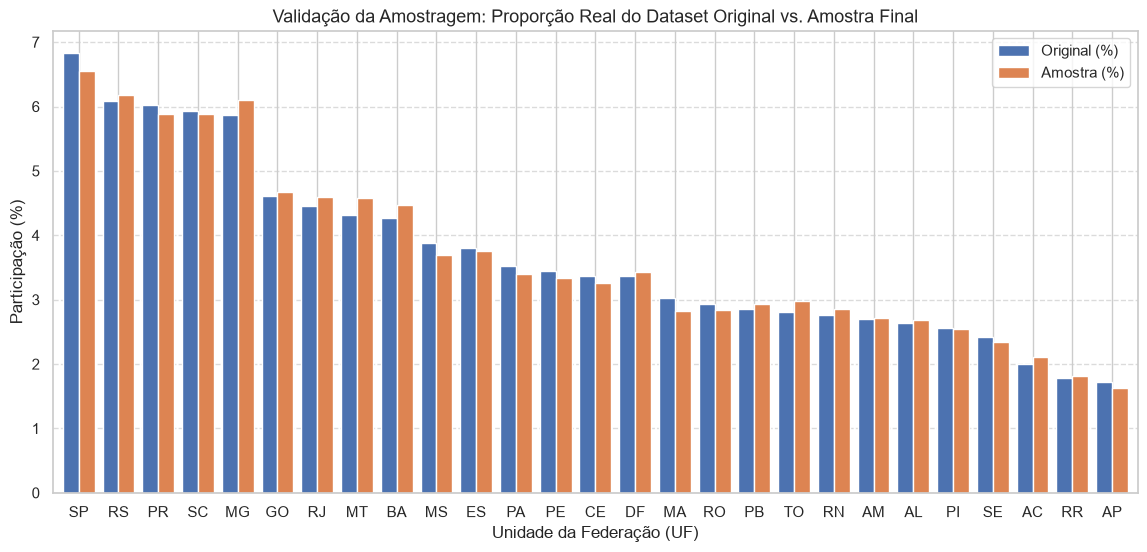

In [7]:
def validar_proporcoes_uf(ano=2024):
    url = f"https://www.bcb.gov.br/pda/desig/scrdata_{ano}.zip"
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, stream=True, timeout=120)
    
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        csv_filename = [f for f in z.namelist() if f.endswith(".csv") or f.endswith(".txt")][0]
        with z.open(csv_filename) as f:
            # Lê apenas a coluna 'uf' de todo o arquivo original para economizar memória
            col_uf_nome = [c for c in pd.read_csv(f, nrows=5, sep=";", encoding="latin1").columns if 'uf' in c.lower()][0]
            f.seek(0)
            df_full_uf = pd.read_csv(f, sep=";", encoding="latin1", usecols=[col_uf_nome], low_memory=False)
            df_full_uf.columns = ['uf']

    # Calcula as porcentagens do universo original completo
    orig_prop = df_full_uf['uf'].value_counts(normalize=True).mul(100).rename("Original (%)")
    
    # Calcula as porcentagens da sua amostra (df_scr_raw)
    col_amostra_uf = [c for c in df_scr_raw.columns if 'uf' in c.lower()][0]
    samp_prop = df_scr_raw[col_amostra_uf].value_counts(normalize=True).mul(100).rename("Amostra (%)")
    
    # Junta em um DataFrame de comparação
    df_comparacao = pd.concat([orig_prop, samp_prop], axis=1).fillna(0)
    df_comparacao["Diferença Absoluta (%)"] = (df_comparacao["Original (%)"] - df_comparacao["Amostra (%)"]).abs()
    
    print("---TABELA COMPARATIVA DE PROPORÇÕES POR UF ---")
    display(df_comparacao.round(4))
    
    # Gráfico comparativo
    plt.figure(figsize=(14, 6))
    df_comparacao[['Original (%)', 'Amostra (%)']].plot(kind='bar', figsize=(14, 6), width=0.8)
    plt.title("Validação da Amostragem: Proporção Real do Dataset Original vs. Amostra Final", fontsize=13)
    plt.xlabel("Unidade da Federação (UF)")
    plt.ylabel("Participação (%)")
    plt.xticks(rotation=0)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Executa a checagem estatística
validar_proporcoes_uf(ano=2024)

C:\Users\adria\AppData\Local\Temp\ipykernel_2984\1433241308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


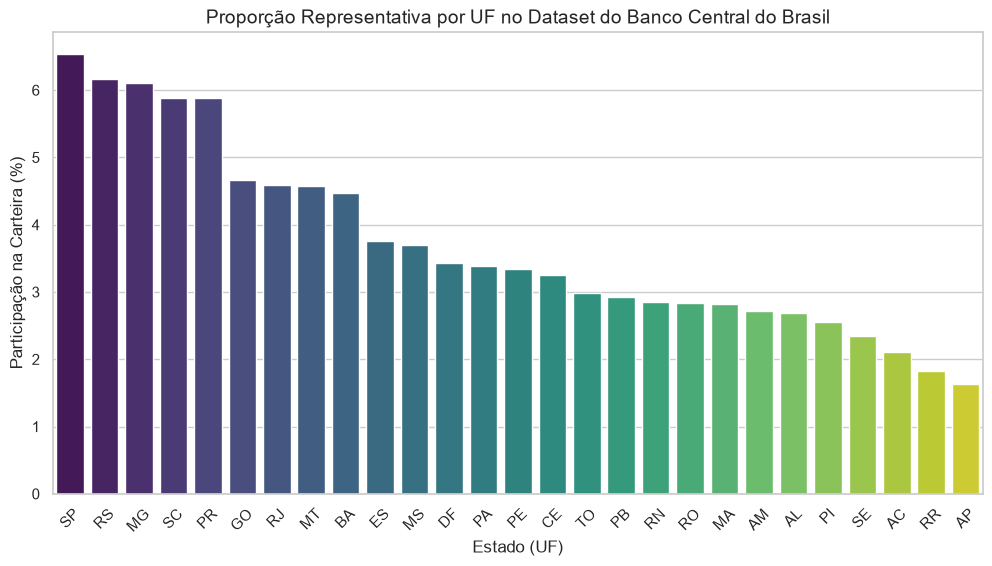

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_distribuicao,
    x="UF",
    y="Proporção na Amostra (%)",
    palette="viridis"
)
plt.title("Proporção Representativa por UF no Dataset do Banco Central do Brasil", fontsize=14)
plt.xlabel("Estado (UF)")
plt.ylabel("Participação na Carteira (%)")
plt.xticks(rotation=45)
plt.show()

--- ÚLTIMAS LEITURAS DE INADIMPLÊNCIA PF NO BRASIL (SGS 21112) ---
         data  valor
74 2026-03-01   7.25
75 2026-04-01   7.37
76 2026-05-01   7.55
77 2026-06-01   7.37
78 2026-07-01   7.79

--- ÚLTIMAS LEITURAS DA TAXA SELIC (SGS 432) ---
           data  valor
2446 2026-09-12   14.0
2447 2026-09-13   14.0
2448 2026-09-14   14.0
2449 2026-09-15   14.0
2450 2026-09-16   14.0


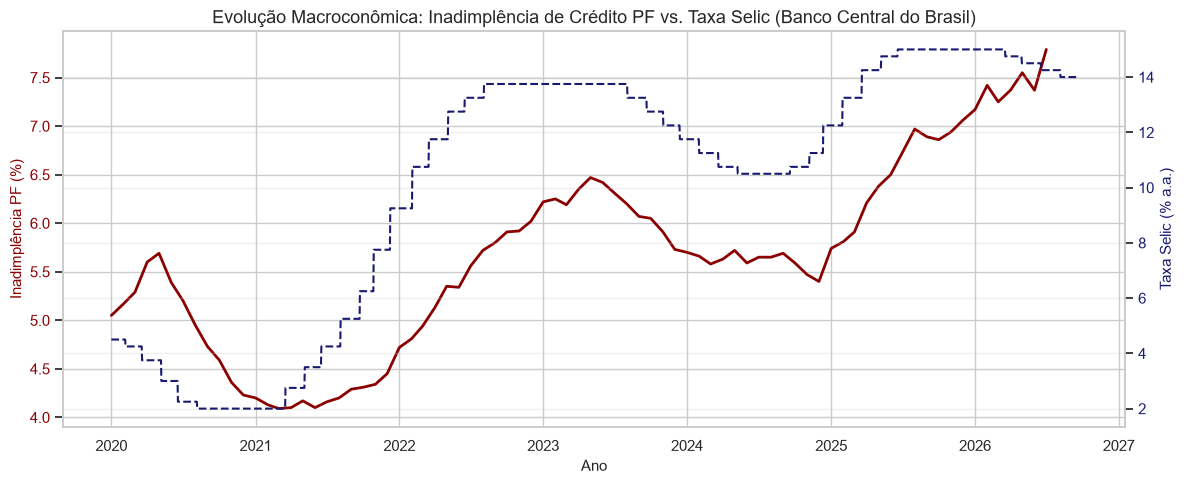

In [9]:
def consultar_sgs_bcb(codigo_serie, data_inicio="01/01/2020"):
    """Consulta a API do SGS (Sistema Gerenciador de Séries Temporais) do BCB."""
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?formato=json&dataInicial={data_inicio}"
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Accept": "application/json"
    }
    
    resp = requests.get(url, headers=headers, timeout=15)
    resp.raise_for_status()
    
    df = pd.DataFrame(resp.json())
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = df['valor'].astype(float)
    return df

# Séries SGS Oficiais do BCB:
# 21112 = Inadimplência da carteira de crédito - PF Total (%)
# 432   = Taxa de juros - Selic Meta (% a.a.)
df_inadimplencia = consultar_sgs_bcb(21112)
df_selic = consultar_sgs_bcb(432)

print("--- ÚLTIMAS LEITURAS DE INADIMPLÊNCIA PF NO BRASIL (SGS 21112) ---")
print(df_inadimplencia.tail(5))

print("\n--- ÚLTIMAS LEITURAS DA TAXA SELIC (SGS 432) ---")
print(df_selic.tail(5))

# Plotagem do gráfico de linhas duplo
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eixo 1: Inadimplência
color = 'darkred'
ax1.set_xlabel('Ano', fontsize=11)
ax1.set_ylabel('Inadimplência PF (%)', color=color, fontsize=11)
line1 = ax1.plot(df_inadimplencia['data'], df_inadimplencia['valor'], color=color, linewidth=2, label="Inadimplência PF (%)")
ax1.tick_params(axis='y', labelcolor=color)

# Eixo 2: Taxa Selic
ax2 = ax1.twinx()  
color = 'midnightblue'
ax2.set_ylabel('Taxa Selic (% a.a.)', color=color, fontsize=11)
line2 = ax2.plot(df_selic['data'], df_selic['valor'], color=color, linewidth=1.5, linestyle="--", label="Selic Meta (%)")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Evolução Macroconômica: Inadimplência de Crédito PF vs. Taxa Selic (Banco Central do Brasil)", fontsize=13)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# --- AED DAS SÉRIES MACROECONÔMICAS DO SGS (SELIC E INADIMPLÊNCIA) ---

print("--- ESTATÍSTICAS DESCRITIVAS DA TAXA SELIC (%) ---")
display(df_selic['valor'].describe().round(2).to_frame().T)

print("\n--- ESTATÍSTICAS DESCRITIVAS DA INADIMPLÊNCIA PF (%) ---")
display(df_inadimplencia['valor'].describe().round(2).to_frame().T)

# Correlação de Pearson entre Selic e Inadimplência
df_macro = pd.merge_asof(
    df_inadimplencia.sort_values('data'), 
    df_selic.sort_values('data'), 
    on='data', 
    suffixes=('_inad', '_selic')
)

correlacao = df_macro['valor_inad'].corr(df_macro['valor_selic'])
print(f"\nCorrelação entre Taxa Selic e Inadimplência PF: {correlacao:.4f}")

--- ESTATÍSTICAS DESCRITIVAS DA TAXA SELIC (%) ---


,count,mean,std,min,25%,50%,75%,max
valor,2451.0,10.27,4.6,2.0,5.25,12.25,13.75,15.0



--- ESTATÍSTICAS DESCRITIVAS DA INADIMPLÊNCIA PF (%) ---


,count,mean,std,min,25%,50%,75%,max
valor,79.0,5.66,0.96,4.09,5.0,5.69,6.24,7.79



Correlação entre Taxa Selic e Inadimplência PF: 0.8314


In [11]:
col_vencido_90 = [c for c in df_scr_raw.columns if 'vencido_acima_de_90' in c][0]
col_carteira = [c for c in df_scr_raw.columns if c in ['carteira_ativa', 'carteira_a_vencer']][0]

df_scr_raw['taxa_inad_real'] = df_scr_raw[col_vencido_90] / (df_scr_raw[col_carteira] + 1e-5)
df_scr_raw['target_default'] = (df_scr_raw[col_vencido_90] > 0).astype(int)

print(f"--- PROPORÇÃO GERAL DE INADIMPLÊNCIA NA AMOSTRA ---")
print(f"Taxa Média de Inadimplência Binária (Target > 0): {df_scr_raw['target_default'].mean() * 100:.2f}%")
print(f"Taxa Média de Inadimplência Financeira Relativa: {df_scr_raw['taxa_inad_real'].mean() * 100:.2f}%\n")

# 2. Análise por Modalidade de Crédito
print("--- TOP 10 MODALIDADES COM MAIOR TAXA DE DEFAULT ---")
display(
    df_scr_raw.groupby('modalidade')['target_default']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'Qtd_Registros', 'mean': 'Taxa_Default_%'})
    .assign(Taxa_Default_perc=lambda x: (x['Taxa_Default_%'] * 100).round(2))
    .drop(columns=['Taxa_Default_%'])
    .sort_values(by='Taxa_Default_perc', ascending=False)
    .head(10)
)

--- PROPORÇÃO GERAL DE INADIMPLÊNCIA NA AMOSTRA ---
Taxa Média de Inadimplência Binária (Target > 0): 42.53%
Taxa Média de Inadimplência Financeira Relativa: 94002721037.05%

--- TOP 10 MODALIDADES COM MAIOR TAXA DE DEFAULT ---


,Qtd_Registros,Taxa_Default_perc
modalidade,,
Adiantamentos a depositantes,430,83.49
Empréstimos,7545,54.59
Financiamentos,2852,36.19
Direitos creditórios descontados,381,30.97
Outros créditos,1972,26.22
Financiamentos rurais (ex-financiamentos rurais e agroindustriais),1217,23.09
Financiamentos imobiliários,877,21.32
Financiamentos à importação,15,13.33
Financiamentos de títulos e valores mobiliários,10,10.00


In [12]:
# Filtra apenas colunas numéricas
df_num = df_scr_raw.select_dtypes(include=[np.number])

# Calcula a correlação de todas as variáveis numéricas com o Target
correlacoes = df_num.corr()['target_default'].sort_values(ascending=False).round(4)

print("--- RANKING DE CORRELAÇÃO COM O TARGET (DIAGNÓSTICO DE LEAKAGE) ---")
display(correlacoes.to_frame(name="Correlação com target_default"))

--- RANKING DE CORRELAÇÃO COM O TARGET (DIAGNÓSTICO DE LEAKAGE) ---


,Correlação com target_default
target_default,1.0000
vencido_de_15_ate_90_dias,0.1268
carteira_vencida,0.0939
carteira_inadimplencia,0.0748
vencido_acima_de_90_dias,0.0748
numero_de_operacoes,0.0614
a_vencer_de_361_ate_1080_dias,0.0520
a_vencer_de_91_ate_360_dias,0.0468
carteira_ativa,0.0440
a_vencer_de_1081_ate_1800_dias,0.0436


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

# Prepara dados rápidos para o teste
df_eda_model = df_scr_raw.copy()

# Remove colunas óbvias de resultado financeiro em atraso
cols_to_drop = ['target_default', 'taxa_inad_real', col_vencido_90]
if 'carteira_inadimplencia' in df_eda_model.columns: cols_to_drop.append('carteira_inadimplencia')
if 'carteira_vencida' in df_eda_model.columns: cols_to_drop.append('carteira_vencida')
if 'vencido_de_15_ate_90_dias' in df_eda_model.columns: cols_to_drop.append('vencido_de_15_ate_90_dias')

X_eda = df_eda_model.drop(columns=[c for c in cols_to_drop if c in df_eda_model.columns])
y_eda = df_eda_model['target_default']

# Codifica colunas de texto
for col in X_eda.select_dtypes(include=['object']).columns:
    X_eda[col] = OrdinalEncoder().fit_transform(X_eda[[col]].astype(str))

X_eda = X_eda.fillna(0)

# Treina Random Forest rápida
rf_diag = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42)
rf_diag.fit(X_eda, y_eda)

# Exibe o ranking de importância
df_importance = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importancia (%)': (rf_diag.feature_importances_ * 100).round(2)
}).sort_values(by='Importancia (%)', ascending=False)

print("--- TOP 10 FEATURES MAIS IMPORTANTES NO DATASET ---")
display(df_importance.head(10))

--- TOP 10 FEATURES MAIS IMPORTANTES NO DATASET ---


,Feature,Importancia (%)
19,ativo_problematico,55.74
10,numero_de_operacoes,15.42
6,modalidade,6.46
17,carteira_a_vencer,4.41
11,a_vencer_ate_90_dias,3.51
9,indexador,2.64
7,submodalidade,2.14
14,a_vencer_de_1081_ate_1800_dias,1.82
18,carteira_ativa,1.39
12,a_vencer_de_91_ate_360_dias,1.30


In [14]:
# --- RE-CALIBRAÇÃO DO TARGET E TRATAMENTO DE LEAKAGE ---

# 1. Ajusta o denominador tratando linhas com carteira ativa insignificante (evita divisões aberrantes)
df_eda_clean = df_scr_raw[df_scr_raw['carteira_ativa'] > 10.0].copy()

# 2. Taxa de inadimplência percentual real da linha agregada
df_eda_clean['taxa_inad_perc'] = (
    df_eda_clean['vencido_acima_de_90_dias'] / df_eda_clean['carteira_ativa']
)

# 3. Target Regulatório Calibrado: Operações cujo percentual de inadimplência supera 5% da carteira
df_eda_clean['target_default_calibrado'] = (df_eda_clean['taxa_inad_perc'] > 0.05).astype(int)

# 4. Avaliação de Importância Sem Vazamento Causal de Submodalidade
cols_vazamento = [
    'target_default', 'target_default_calibrado', 'taxa_inad_perc', 'taxa_inad_real',
    'vencido_acima_de_90_dias', 'vencido_de_15_ate_90_dias', 'carteira_inadimplencia',
    'carteira_vencida', 'ativo_problematico', 'submodalidade' # Remove atalho categórico
]

X_clean = df_eda_clean.drop(columns=[c for c in cols_vazamento if c in df_eda_clean.columns])
y_clean = df_eda_clean['target_default_calibrado']

for col in X_clean.select_dtypes(include=['object']).columns:
    X_clean[col] = OrdinalEncoder().fit_transform(X_clean[[col]].astype(str))

X_clean = X_clean.fillna(0)

# Treina modelo de teste calibrado
rf_clean = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42)
rf_clean.fit(X_clean, y_clean)

df_imp_clean = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importancia (%)': (rf_clean.feature_importances_ * 100).round(2)
}).sort_values(by='Importancia (%)', ascending=False)

print(f"--- NOVA TAXA DE DEFAULT CALIBRADA (Padrão Bacen > 5%): {y_clean.mean() * 100:.2f}% ---")
print("--- NOVO RANKING DE IMPORTÂNCIA (SEM LEAKAGE) ---")
display(df_imp_clean.head(10))

--- NOVA TAXA DE DEFAULT CALIBRADA (Padrão Bacen > 5%): 23.00% ---
--- NOVO RANKING DE IMPORTÂNCIA (SEM LEAKAGE) ---


,Feature,Importancia (%)
16,carteira_a_vencer,25.25
6,modalidade,20.35
9,numero_de_operacoes,16.12
11,a_vencer_de_91_ate_360_dias,8.70
8,indexador,7.74
10,a_vencer_ate_90_dias,4.70
12,a_vencer_de_361_ate_1080_dias,4.14
17,carteira_ativa,3.10
13,a_vencer_de_1081_ate_1800_dias,3.02
14,a_vencer_de_1801_ate_5400_dias,1.80


Carregando modelo diretamente de: artifacts/champion_model.pkl
Modelo pipeline do CatBoost carregado com sucesso!

CLASSIFICATION REPORT (AMOSTRA COMPLETA DO BCB)
                 precision    recall  f1-score   support

Bom Pagador (0)       0.93      0.96      0.95     22611
    Default (1)       0.86      0.78      0.82      7266

       accuracy                           0.92     29877
      macro avg       0.90      0.87      0.88     29877
   weighted avg       0.92      0.92      0.92     29877



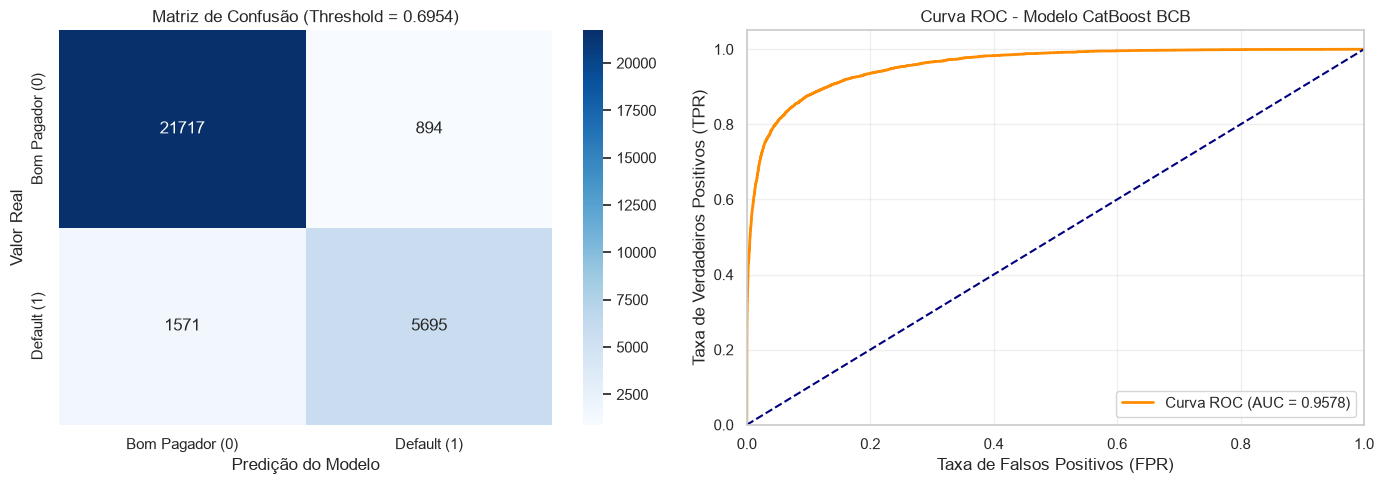

In [15]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Carregamento ultra-rápido e direto via Joblib
model_path = "artifacts/champion_model.pkl"
print(f"Carregando modelo diretamente de: {model_path}")

pipeline = joblib.load(model_path)
print("Modelo pipeline do CatBoost carregado com sucesso!")

# 2. Carrega a base processada do BCB e aplica a engenharia de features
from src.feature_engineering import feature_engineering_avancada, load_income_bins

raw_df = pd.read_parquet("data/processed/bcb_credit_sample.parquet")
income_bins = load_income_bins("artifacts/income_bins.json")
df = feature_engineering_avancada(raw_df, income_bins=income_bins)

ignore_cols = ["target_default", "ï»¿data_base", "data_base", "member_id"]
X = df.drop(columns=[c for c in ignore_cols if c in df.columns], errors="ignore")
y = df["target_default"]

# 3. Predição com o Threshold Otimizado (0.6954)
thresh_otimizado = 0.6954
y_proba = pipeline.predict_proba(X)[:, 1]
y_pred = (y_proba >= thresh_otimizado).astype(int)

# --- RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ---
print("\n" + "="*55)
print("CLASSIFICATION REPORT (AMOSTRA COMPLETA DO BCB)")
print("="*55)
print(classification_report(y, y_pred, target_names=["Bom Pagador (0)", "Default (1)"]))

# --- PLOTAGEM DA MATRIZ DE CONFUSÃO E CURVA ROC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusão
cm = confusion_matrix(y, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    ax=axes[0],
    xticklabels=["Bom Pagador (0)", "Default (1)"],
    yticklabels=["Bom Pagador (0)", "Default (1)"]
)
axes[0].set_title(f"Matriz de Confusão (Threshold = {thresh_otimizado})", fontsize=12)
axes[0].set_ylabel("Valor Real")
axes[0].set_xlabel("Predição do Modelo")

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"Curva ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
axes[1].set_title("Curva ROC - Modelo CatBoost BCB", fontsize=12)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()